# Taller modelos lineales de clasificación - Regresión logística

Sintonice y enrene un modelo de regresión logística para predecir la variable `Churn Label` del dataset **"telco-customer-churn.csv"**, cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Elimine variables que son claves primaria y que son constantes. También elimine las siguientes variables: Lat Long, Churn Value, Churn Reason, Churn Score.

## Modelo 1

Debe usar `Pipeline` y `ColumnTransformer` para crear un flujo que integre el procesamiento de los datos y el modelado, de manera que evite la fuga de datos.

El procesamiento de los datos debe incluir las siguientes transformaciones:
- Estandarización de variables numéricas
- Imputación de datos nulos
- Codificación de variables categóricas

Escoja una métrica que priorice la clasificación correcta de los clientes que se retiran. Con esta métrica sintonice `C` y `l1_ratio`.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

## Modelo 2

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

Vuelva a entrenar y sintonizar el modelo, pero ahora seleccione una métrica que priorice etiquetar correctamente a los clientes que no se han retirado.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

**Advertencia:** El entrenamiento de los modelos puede tardar más de 10 minutos. No se preocupe, este es normal. Para reducir un poco el tiempo de entrenamiento pruebe solo 20 valores de `C` y 5 de `l1_ratio`.


Elimine variables que son claves primaria y que son constantes. También elimine las siguientes variables: Lat Long, Churn Value, Churn Reason, Churn Score.


In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
#Aqui se esta leyendo el archivo csv y se esta guardando en un dataframe llamado df, 

DATA_DIR = Path().resolve().parent / "data" / "raw"
FILE_PATH = "Telco_customer_churn.csv"
df = pd.read_csv(DATA_DIR / FILE_PATH,na_values=['NA'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
df = df.drop(columns=['CustomerID', 'Lat Long', 'Churn Value', 'Churn Reason', 'Churn Score'])
df =  df.drop_duplicates()

In [5]:
df.head()

,Count,Country,State,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,1,United States,California,Los Angeles,90003,33.964131,-118.272783,Male,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,1,United States,California,Los Angeles,90005,34.059281,-118.307420,Female,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,1,United States,California,Los Angeles,90006,34.048013,-118.293953,Female,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,5372
3,1,United States,California,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,5003
4,1,United States,California,Los Angeles,90015,34.039224,-118.266293,Male,No,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,5340


## Modelo 1

Debe usar `Pipeline` y `ColumnTransformer` para crear un flujo que integre el procesamiento de los datos y el modelado, de manera que evite la fuga de datos.

El procesamiento de los datos debe incluir las siguientes transformaciones:
- Estandarización de variables numéricas
- Imputación de datos nulos
- Codificación de variables categóricas

Escoja una métrica que priorice la clasificación correcta de los clientes que se retiran. Con esta métrica sintonice `C` y `l1_ratio`.


In [6]:
df.describe().T # revision de las numericas

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [7]:
#Estadistica de las categoricas
df.describe(include="object").T

/tmp/ipykernel_6326/2127312426.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361
Multiple Lines,7043,3,No,3390
Internet Service,7043,3,Fiber optic,3096


In [8]:
df = df.drop(columns=['Country', 'State'])

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.impute import SimpleImputer

ohe = OneHotEncoder(sparse_output=False, drop='first')
ss = StandardScaler()


In [10]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [11]:
from sklearn.pipeline import Pipeline

imputer = SimpleImputer(strategy='mean')

numerics = Pipeline([
    ('imputer', imputer),
    ('ss',ss)
    ])

preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 
                  'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 
                  'Contract', 'Paperless Billing', 'Payment Method']),
    ('proc_num', numerics, ['Count', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV'])
    ],
    remainder='drop')

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('proc_num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [12]:
X = df.drop(columns=['Churn Label'])
le = LabelEncoder()
y = le.fit_transform(df['Churn Label'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ohe', ...), ('proc_num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [19]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score



grid = {
    'model__penalty':['l1'], # tipo de regularización
    'model__C':np.logspace(-1,3,50), # inverso del factor de regularización
    #'l1_ratio':[0, 0.1, 0.5, 0.9, 1], # si tipo de regularización es elasticnet, define que tanto peso se la da a cada tipo de regularización
    'model__solver':['saga'] # algoritmo de optimización, saga es el único que soporta elasticnet
    }

grid_search = GridSearchCV(
    pipeline,
    param_grid=grid,
    cv=5,
    scoring='recall'
    )

grid_search.fit(X_train, y_train)
#train_score = precision_score(y_train, grid_search.best_estimator_.predict(X_train))
#test_score = precision_score(y_test, grid_search.best_estimator_.predict(X_test))

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

Cross-validation score: 0.588, best hyperparameters: {'model__C': np.float64(49.41713361323833), 'model__penalty': 'l1', 'model__solver': 'saga'}
Train score: 0.592
Test score: 0.578


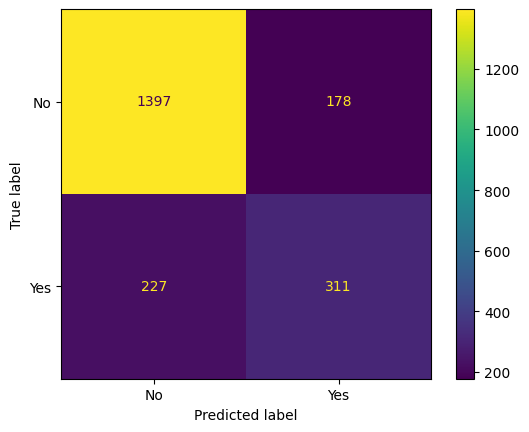

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    )

In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

          No       0.86      0.89      0.87      1575
         Yes       0.64      0.58      0.61       538

    accuracy                           0.81      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.80      0.81      0.81      2113




## Modelo 2

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

Vuelva a entrenar y sintonizar el modelo, pero ahora seleccione una métrica que priorice etiquetar correctamente a los clientes que no se han retirado.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

**Advertencia:** El entrenamiento de los modelos puede tardar más de 10 minutos. No se preocupe, este es normal. Para reducir un poco el tiempo de entrenamiento pruebe solo 20 valores de `C` y 5 de `l1_ratio`.


In [18]:
pipeline = grid_search.best_estimator_

model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessing']

# nombres reales de las features después del preprocessing
feature_names = preprocessor.get_feature_names_out()

# coeficientes
coef = model.coef_[0]

# dataframe
pesos = pd.DataFrame({
    'feature': feature_names,
    'peso': coef
})

# ordenar por importancia (valor absoluto)
pesos = pesos.sort_values(by='peso', ascending=False)

pesos.head(20)

,feature,peso
7,ohe__Internet Service_Fiber optic,0.638343
30,proc_num__Total Charges,0.490640
23,ohe__Paperless Billing_Yes,0.328230
2,ohe__Partner_Yes,0.317583
5,ohe__Multiple Lines_No phone service,0.299012
25,ohe__Payment Method_Electronic check,0.273144
20,ohe__Streaming Movies_Yes,0.259624
29,proc_num__Monthly Charges,0.247291
6,ohe__Multiple Lines_Yes,0.236613
1,ohe__Senior Citizen_Yes,0.087289


In [20]:
grid = {
    'model__penalty':['l1'], # tipo de regularización
    'model__C':np.logspace(-1,3,50), # inverso del factor de regularización
    #'l1_ratio':[0, 0.1, 0.5, 0.9, 1], # si tipo de regularización es elasticnet, define que tanto peso se la da a cada tipo de regularización
    'model__solver':['saga'] # algoritmo de optimización, saga es el único que soporta elasticnet
    }

grid_search = GridSearchCV(
    pipeline,
    param_grid=grid,
    cv=5,
    scoring='precision'
    )

grid_search.fit(X_train, y_train)
#train_score = precision_score(y_train, grid_search.best_estimator_.predict(X_train))
#test_score = precision_score(y_test, grid_search.best_estimator_.predict(X_test))

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

Cross-validation score: 0.671, best hyperparameters: {'model__C': np.float64(0.14563484775012436), 'model__penalty': 'l1', 'model__solver': 'saga'}
Train score: 0.675
Test score: 0.637


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    )

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))